In [117]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.utils import class_weight
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve



# Define the column names based on the CSV information:
# 14 independent variables followed by the dependent variable.
column_names = [
    "First_Term_Gpa", "Second_Term_Gpa", "First_Language", "Funding",
    "School", "FastTrack", "Coop", "Residency",
    "Gender", "Previous_Education", "Age_Group", "High_School_Average_Mark",
    "Math_Score", "English_Grade", "FirstYearPersistence"
]

# Read the CSV file.
# Skip the first 24 rows which contain metadata and extra headings,
# and assign the column names manually. We also specify that any "?" should be parsed as NaN.
df = pd.read_csv("Student data.csv", skiprows=24, header=None, names=column_names, na_values=["?"])

# Display the first few rows of the dataframe to verify
df.head()


,First_Term_Gpa,Second_Term_Gpa,First_Language,Funding,School,FastTrack,Coop,Residency,Gender,Previous_Education,Age_Group,High_School_Average_Mark,Math_Score,English_Grade,FirstYearPersistence
0,0.000000,0.000000,1.0,2,6,2,1,1,2,1.0,1.0,59.0,16.0,7.0,1
1,2.500000,2.000000,3.0,4,6,1,2,2,2,1.0,3.0,NaN,NaN,7.0,1
2,4.250000,3.923077,1.0,1,6,2,1,1,1,2.0,3.0,92.0,41.0,9.0,1
3,3.020833,2.321429,3.0,4,6,1,2,2,2,2.0,3.0,NaN,NaN,8.0,1
4,4.275000,4.326923,1.0,2,6,1,1,1,1,2.0,3.0,97.0,NaN,9.0,1


In [90]:
print(df.info())
print("Shape of the dataframe",df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1437 entries, 0 to 1436
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   First_Term_Gpa            1420 non-null   float64
 1   Second_Term_Gpa           1277 non-null   float64
 2   First_Language            1326 non-null   float64
 3   Funding                   1437 non-null   int64  
 4   School                    1437 non-null   int64  
 5   FastTrack                 1437 non-null   int64  
 6   Coop                      1437 non-null   int64  
 7   Residency                 1437 non-null   int64  
 8   Gender                    1437 non-null   int64  
 9   Previous_Education        1433 non-null   float64
 10  Age_Group                 1433 non-null   float64
 11  High_School_Average_Mark  694 non-null    float64
 12  Math_Score                975 non-null    float64
 13  English_Grade             1392 non-null   float64
 14  FirstYea

In [91]:
# Check missing values
df.isnull().sum()

First_Term_Gpa               17
Second_Term_Gpa             160
First_Language              111
Funding                       0
School                        0
FastTrack                     0
Coop                          0
Residency                     0
Gender                        0
Previous_Education            4
Age_Group                     4
High_School_Average_Mark    743
Math_Score                  462
English_Grade                45
FirstYearPersistence          0
dtype: int64

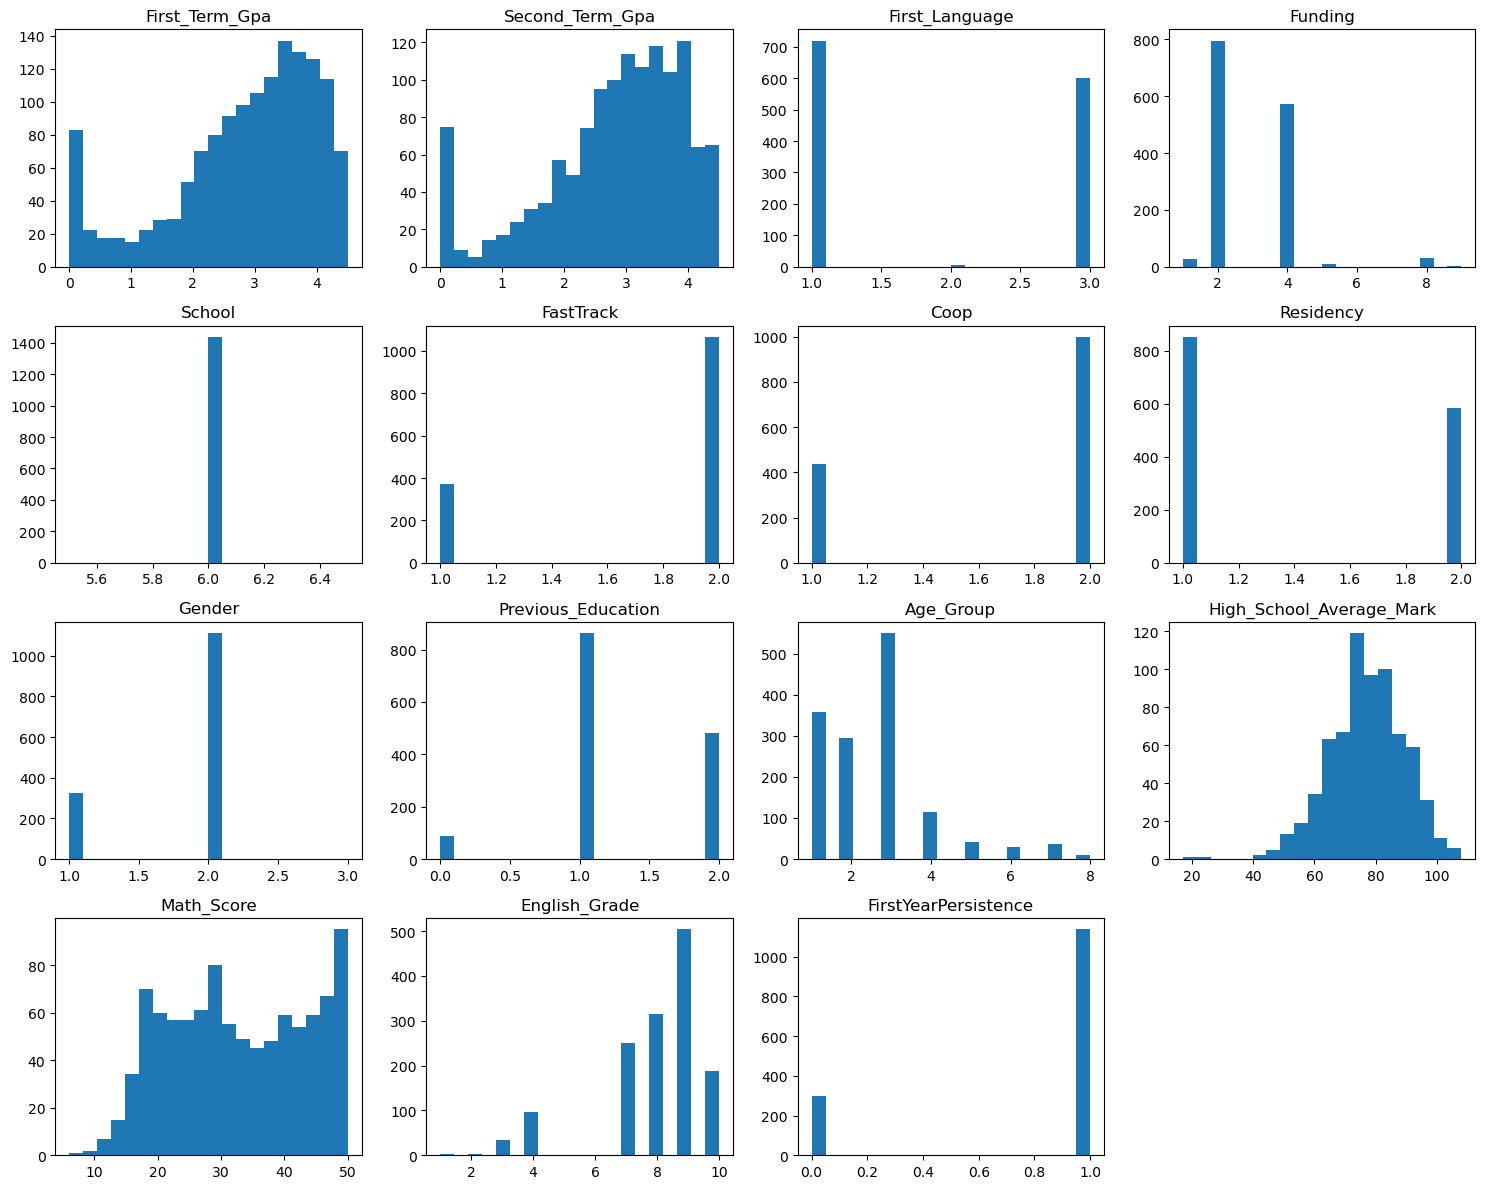

In [92]:
# Plot all columns as histograms
df.hist(figsize=(15, 12), bins=20, grid=False)
plt.tight_layout()
plt.show()

In [ ]:
# GPA columns – Median Imputation (due to skewness)
df['First_Term_Gpa'].fillna(df['First_Term_Gpa'].median(), inplace=True)
df['Second_Term_Gpa'].fillna(df['Second_Term_Gpa'].median(), inplace=True)

# 2. High_School_Average_Mark – Mean (normal distribution)
df['High_School_Average_Mark'].fillna(df['High_School_Average_Mark'].mean(), inplace=True)

# 3. Math_Score – Median (right-skewed)
df['Math_Score'].fillna(df['Math_Score'].median(), inplace=True)

# 4. English_Grade – Mode (ordinal/categorical)
df['English_Grade'].fillna(df['English_Grade'].mode()[0], inplace=True)

# 5. First_Language – Mode (categorical)
df['First_Language'].fillna(df['First_Language'].mode()[0], inplace=True)

# 6. Previous_Education & Age_Group – Mode (categorical)
for col in ['Previous_Education', 'Age_Group']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# 7. Funding, FastTrack, Coop, Residency, Gender – Mode (categorical/binary)
for col in ['Funding', 'FastTrack', 'Coop', 'Residency', 'Gender']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# 9. Drop 'School' if it's constant (e.g., only one unique value)
if df['School'].nunique() == 1:
    df.drop('School', axis=1, inplace=True)


    

In [101]:
# Step 4: Final validation
print("✅ Final shape:", df.shape)
print("\n🔍 Remaining missing values:\n")
print(df.isnull().sum())

# Optional: Preview cleaned data
df.head()

✅ Final shape: (1437, 14)

🔍 Remaining missing values:

First_Term_Gpa              0
Second_Term_Gpa             0
First_Language              0
Funding                     0
FastTrack                   0
Coop                        0
Residency                   0
Gender                      0
Previous_Education          0
Age_Group                   0
High_School_Average_Mark    0
Math_Score                  0
English_Grade               0
FirstYearPersistence        0
dtype: int64


,First_Term_Gpa,Second_Term_Gpa,First_Language,Funding,FastTrack,Coop,Residency,Gender,Previous_Education,Age_Group,High_School_Average_Mark,Math_Score,English_Grade,FirstYearPersistence
0,0.000000,0.000000,1.0,2,2,1,1,2,1.0,1.0,59.000000,16.0,7.0,1
1,2.500000,2.000000,3.0,4,1,2,2,2,1.0,3.0,77.152738,32.0,7.0,1
2,4.250000,3.923077,1.0,1,2,1,1,1,2.0,3.0,92.000000,41.0,9.0,1
3,3.020833,2.321429,3.0,4,1,2,2,2,2.0,3.0,77.152738,32.0,8.0,1
4,4.275000,4.326923,1.0,2,1,1,1,1,2.0,3.0,97.000000,32.0,9.0,1


In [ ]:
df.to_csv("data/Student_Data.csv", index=False)

In [103]:
# Count number of 0.0 GPAs in First_Term_Gpa and Second_Term_Gpa
zero_first_term = (df['First_Term_Gpa'] == 0.0).sum()
zero_second_term = (df['Second_Term_Gpa'] == 0.0).sum()

print(f"📘 Students with 0.0 First Term GPA: {zero_first_term}")
print(f"📗 Students with 0.0 Second Term GPA: {zero_second_term}")


📘 Students with 0.0 First Term GPA: 76
📗 Students with 0.0 Second Term GPA: 72


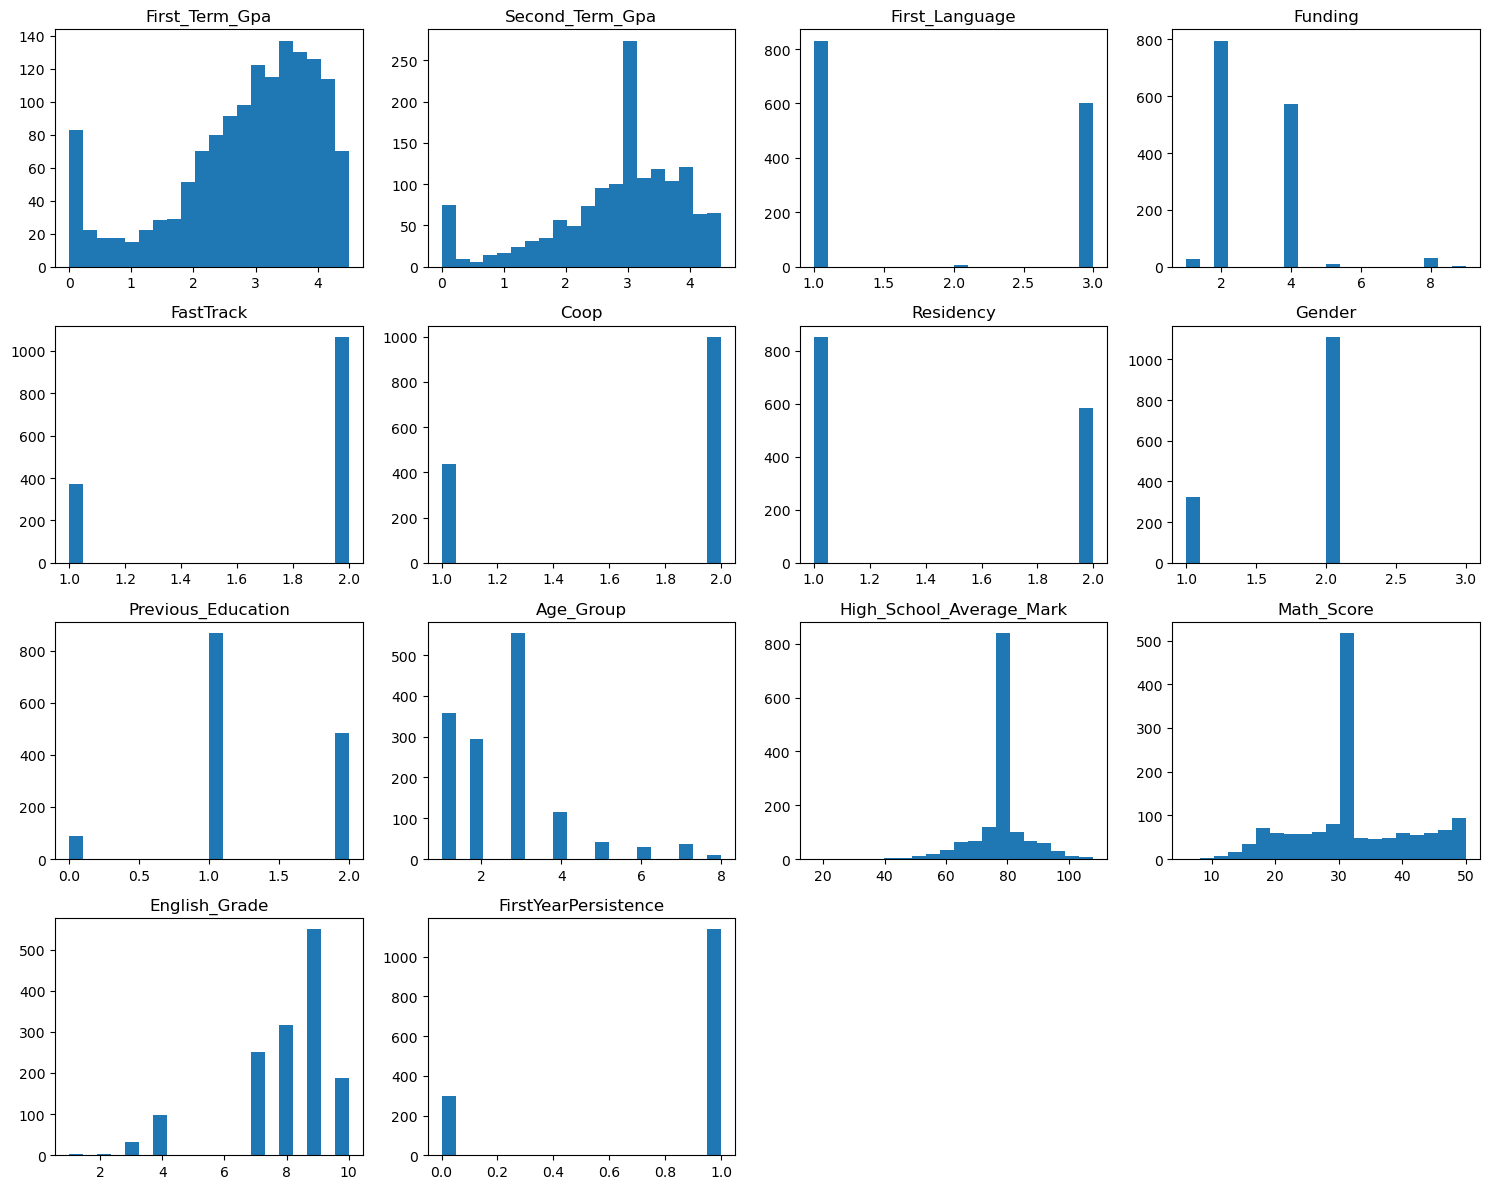

In [104]:
# Plot all columns as histograms
df.hist(figsize=(15, 12), bins=20, grid=False)
plt.tight_layout()
plt.show()

In [105]:
# Step 2: Define the target variable and feature set
target = 'FirstYearPersistence'
X = df.drop(columns=[target])
y = df[target]


In [106]:
# Step 3: Categorize feature types

# Numerical features to be standardized
num_features = ['First_Term_Gpa', 'Second_Term_Gpa', 'High_School_Average_Mark', 'Math_Score']

# Ordinal features - left as-is
ordinal_features = ['English_Grade', 'Age_Group', 'Previous_Education']

# Categorical features - one-hot encode
cat_features = ['First_Language', 'Funding', 'Gender', 'FastTrack', 'Coop', 'Residency']

# Step 4: Define preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),          # Scale continuous numerics
    ('ord', 'passthrough', ordinal_features),         # Leave ordinal numeric as-is
    ('cat', OneHotEncoder(drop='first'), cat_features) # One-hot encode categoricals
])

In [107]:
X_processed = preprocessor.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.25, random_state=42, stratify=y
)

# First Approach

In [ ]:
# from sklearn.utils import class_weight


# # Compute class weights
# class_weights = class_weight.compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(y),
#     y=y
# )

# # Convert to dictionary (recommended for model training)
# class_weight_dict = dict(zip(np.unique(y), class_weights))

# # Output class weights
# print("✅ Balanced class weights:")
# print(class_weight_dict)


In [ ]:
# # Build neural network
# model = Sequential([
#     Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
#     Dropout(0.3),
#     Dense(32, activation='relu'),
#     Dense(1, activation='sigmoid')
# ])


In [110]:
# model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])


In [111]:
# Train with class weights
# history = model.fit(
#     X_train, y_train,
#     validation_split=0.2,
#     epochs=30,
#     batch_size=32,
#     class_weight=class_weight_dict,
#     verbose=1
# )


In [112]:
# # Predict probabilities
# y_pred_probs = model.predict(X_test)

# # Tune threshold
# thresholds = [0.5, 0.45, 0.4, 0.35, 0.3]
# for thresh in thresholds:
#     print(f"\n🔽 Threshold: {thresh}")
#     y_pred = (y_pred_probs > thresh).astype("int32")
#     print("📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
#     print("📄 Classification Report:\n", classification_report(y_test, y_pred))

# # Optional: Precision-Recall Curve
# precision, recall, thresh = precision_recall_curve(y_test, y_pred_probs)
# plt.figure(figsize=(8, 5))
# plt.plot(thresh, precision[:-1], label='Precision')
# plt.plot(thresh, recall[:-1], label='Recall')
# plt.xlabel("Threshold")
# plt.ylabel("Score")
# plt.title("Precision vs Recall at Various Thresholds")
# plt.legend()
# plt.grid(True)

# plt.tight_layout()
# plt.show()

# 2nd Approach

In [113]:
#Apply SMOTE to training data only
sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

# Compute class weights
class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train_smote), y=y_train_smote)
class_weight_dict = dict(zip(np.unique(y_train_smote), class_weights))

/Users/achint/anaconda3/lib/python3.11/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [114]:
 #Build improved neural network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_smote.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train_smote, y_train_smote,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    # callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)


Epoch 1/100
43/43 [==============================] - 1s 3ms/step - loss: 0.5753 - accuracy: 0.7075 - val_loss: 0.8534 - val_accuracy: 0.3216
Epoch 2/100
43/43 [==============================] - 0s 1ms/step - loss: 0.4638 - accuracy: 0.7823 - val_loss: 0.6265 - val_accuracy: 0.6287
Epoch 3/100
43/43 [==============================] - 0s 1ms/step - loss: 0.4460 - accuracy: 0.7874 - val_loss: 0.5155 - val_accuracy: 0.6901
Epoch 4/100
43/43 [==============================] - 0s 1ms/step - loss: 0.4413 - accuracy: 0.7955 - val_loss: 0.4885 - val_accuracy: 0.7456
Epoch 5/100
43/43 [==============================] - 0s 988us/step - loss: 0.4245 - accuracy: 0.8079 - val_loss: 0.4729 - val_accuracy: 0.7632
Epoch 6/100
43/43 [==============================] - 0s 1ms/step - loss: 0.4210 - accuracy: 0.8072 - val_loss: 0.4156 - val_accuracy: 0.8158
Epoch 7/100
43/43 [==============================] - 0s 1ms/step - loss: 0.4057 - accuracy: 0.8006 - val_loss: 0.4844 - val_accuracy: 0.7456
Epoch 8/100

In [115]:
#Predict probabilities
y_pred_probs = model.predict(X_test)

# Precision-Recall evaluation
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_probs)
pr_auc = auc(recall, precision)

# Choose best threshold by F1-score
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)
best_thresh = thresholds[np.argmax(f1_scores)]

# Final predictions and report
y_pred = (y_pred_probs > best_thresh).astype("int32")
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

conf_matrix, class_report, best_thresh, pr_auc
print(conf_matrix)
print(class_report)
print(best_thresh)
print(pr_auc)




12/12 [==============================] - 0s 432us/step
[[ 20  55]
 [  3 282]]
              precision    recall  f1-score   support

           0       0.87      0.27      0.41        75
           1       0.84      0.99      0.91       285

    accuracy                           0.84       360
   macro avg       0.85      0.63      0.66       360
weighted avg       0.84      0.84      0.80       360

0.014793245
0.9057776144365688
